In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords


In [2]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

In [4]:
X_train, X_test, y_train, y_test = train_test_split(df["Cleaned_Text"], df["label"], test_size=0.2, random_state=42 , stratify=df["label"] ,shuffle=True)


In [6]:
nltk.download('stopwords')
stop_words = stopwords.words('arabic')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SHIKO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
vectorizer = TfidfVectorizer(max_features=5000 , stop_words=stop_words)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


c:\Users\SHIKO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['آمين', 'أب', 'أخ', 'أفعل', 'أفعله', 'ؤلاء', 'إل', 'إم', 'ات', 'اتان', 'ارتد', 'ان', 'انفك', 'برح', 'تان', 'تبد', 'تحو', 'تعل', 'حد', 'حم', 'حي', 'خب', 'ذار', 'سيما', 'صه', 'ظل', 'ظن', 'عد', 'قط', 'مر', 'مكان', 'مكانكن', 'نب', 'هات', 'هب', 'واها', 'وراء'] not in stop_words.
  warnings.warn(


In [9]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)   

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.69      0.72      0.71      6616
     Neutral       0.59      0.55      0.57      6636
    Positive       0.68      0.70      0.69      6632

    accuracy                           0.66     19884
   macro avg       0.65      0.66      0.65     19884
weighted avg       0.65      0.66      0.65     19884



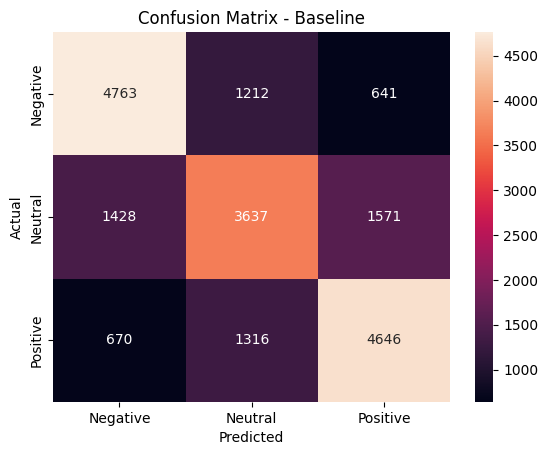

In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline")
plt.show()